<a href="https://colab.research.google.com/github/RogMaverick18/Speech-Processing-Lab-assignments/blob/main/Lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

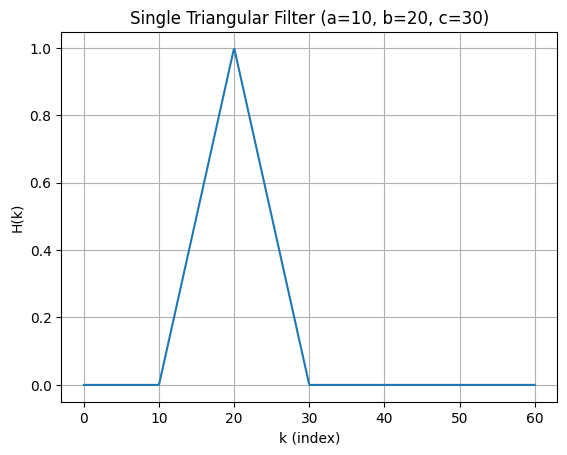

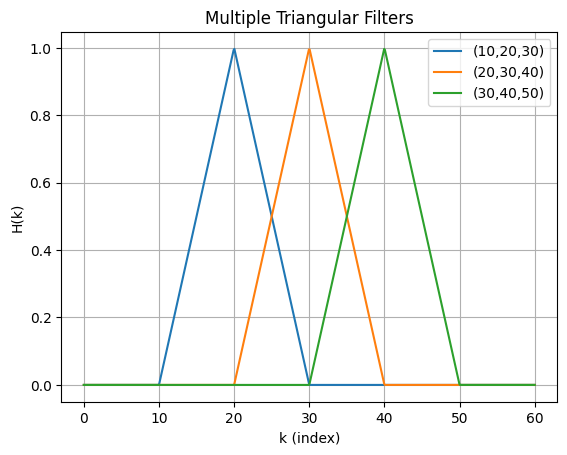

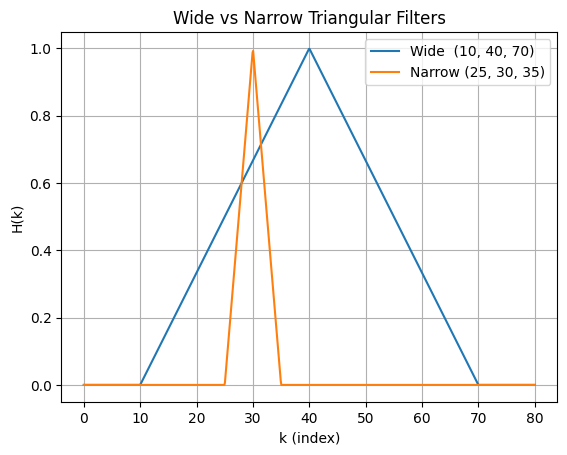

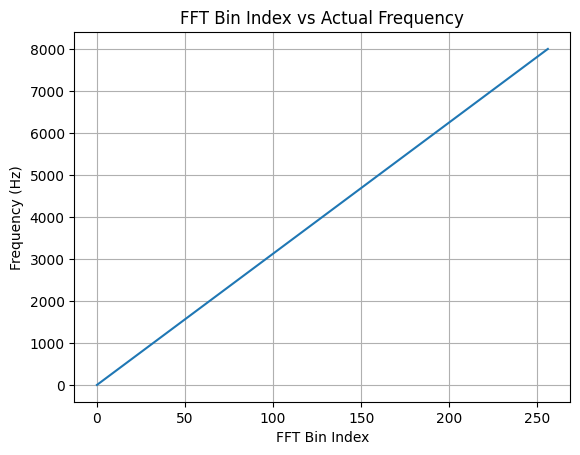

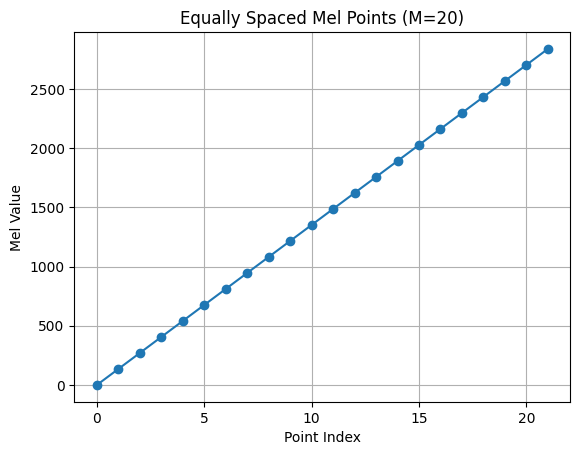

Filter | a    b    c
-------+------------
   1   |   0    2    6
   2   |   2    6    9
   3   |   6    9   13
   4   |   9   13   18
   5   |  13   18   23
   6   |  18   23   29
   7   |  23   29   36
   8   |  29   36   43
   9   |  36   43   52
  10   |  43   52   61
  11   |  52   61   72
  12   |  61   72   84
  13   |  72   84   97
  14   |  84   97  113
  15   |  97  113  130
  16   | 113  130  150
  17   | 130  150  172
  18   | 150  172  196
  19   | 172  196  224
  20   | 196  224  256


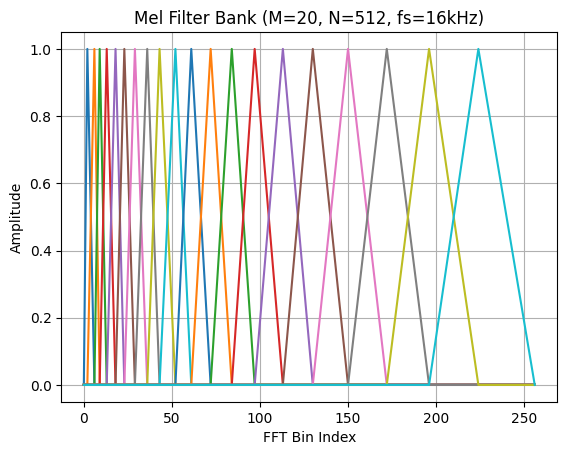

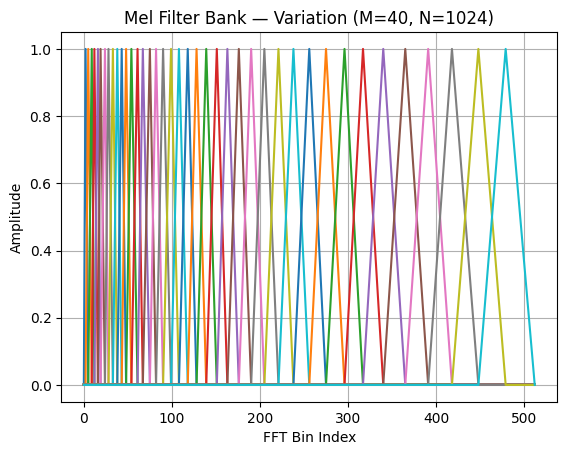

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# OBJECTIVE 1: Triangular Filter Construction

def triangular_filter(k, a, b, c):
    H = np.zeros_like(k, dtype=float)
    rising  = (k >= a) & (k <= b)
    falling = (k >  b) & (k <= c)
    if b != a:
        H[rising]  = (k[rising]  - a) / (b - a)
    if c != b:
        H[falling] = (c - k[falling]) / (c - b)
    return H

k = np.linspace(0, 60, 600)

# Task 1-i: Single triangular filter
plt.figure()
plt.plot(k, triangular_filter(k, 10, 20, 30))
plt.title("Single Triangular Filter (a=10, b=20, c=30)")
plt.xlabel("k (index)")
plt.ylabel("H(k)")
plt.grid(True)
plt.show()

# Task 1-ii: Multiple triangular filters
points_multi = [(10, 20, 30), (20, 30, 40), (30, 40, 50)]
plt.figure()
for (a, b, c) in points_multi:
    plt.plot(k, triangular_filter(k, a, b, c), label=f"({a},{b},{c})")
plt.title("Multiple Triangular Filters")
plt.xlabel("k (index)")
plt.ylabel("H(k)")
plt.legend()
plt.grid(True)
plt.show()

# Task 1-iii: Wide vs Narrow triangle
k2 = np.linspace(0, 80, 800)
plt.figure()
plt.plot(k2, triangular_filter(k2, 10, 40, 70), label="Wide  (10, 40, 70)")
plt.plot(k2, triangular_filter(k2, 25, 30, 35), label="Narrow (25, 30, 35)")
plt.title("Wide vs Narrow Triangular Filters")
plt.xlabel("k (index)")
plt.ylabel("H(k)")
plt.legend()
plt.grid(True)
plt.show()

# OBJECTIVE 2: Mel Filter Bank

# Step 1: Parameters
fs   = 16000   # Sampling frequency (Hz)
N    = 512     # FFT size
M    = 20      # Number of Mel filters
fmin = 0.0
fmax = fs / 2  # Nyquist = 8000 Hz

# Step 2: Convert frequency limits to Mel scale
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)

mel_min = hz_to_mel(fmin)
mel_max = hz_to_mel(fmax)

# Step 3: Generate M+2 equally spaced Mel points
mel_points = np.linspace(mel_min, mel_max, M + 2)

# Step 4: Convert Mel points back to Hz
hz_points = mel_to_hz(mel_points)

# Step 5: Convert Hz to FFT bin indices
bin_points = np.floor((N + 1) * hz_points / fs).astype(int)

# Step 6: Construct triangular filter bank
num_bins = N // 2 + 1
fbank = np.zeros((M, num_bins))

for m in range(M):
    a = bin_points[m]
    b = bin_points[m + 1]
    c = bin_points[m + 2]
    for ki in range(a, b + 1):
        if b != a:
            fbank[m, ki] = (ki - a) / (b - a)
    for ki in range(b, c + 1):
        if c != b:
            fbank[m, ki] = (c - ki) / (c - b)

# (i): FFT Bin vs Frequency
bin_indices = np.arange(num_bins)
freqs_hz    = bin_indices * fs / N

plt.figure()
plt.plot(bin_indices, freqs_hz)
plt.title("FFT Bin Index vs Actual Frequency")
plt.xlabel("FFT Bin Index")
plt.ylabel("Frequency (Hz)")
plt.grid(True)
plt.show()

# (ii): Mel Points
plt.figure()
plt.plot(np.arange(len(mel_points)), mel_points, marker='o')
plt.title("Equally Spaced Mel Points (M=20)")
plt.xlabel("Point Index")
plt.ylabel("Mel Value")
plt.grid(True)
plt.show()

# (iii): Print filter (a, b, c) values
print("Filter | a    b    c")
print("-------+------------")
for m in range(M):
    a, b, c = bin_points[m], bin_points[m+1], bin_points[m+2]
    print(f"  {m+1:2d}   | {a:3d}  {b:3d}  {c:3d}")

# (iv): Mel Filter Bank plot
plt.figure()
for m in range(M):
    plt.plot(bin_indices, fbank[m])
plt.title("Mel Filter Bank (M=20, N=512, fs=16kHz)")
plt.xlabel("FFT Bin Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# (v): Parameter variation — change M and N
fs2, N2, M2 = 16000, 1024, 40
mel_points2  = np.linspace(hz_to_mel(0), hz_to_mel(fs2/2), M2 + 2)
hz_points2   = mel_to_hz(mel_points2)
bin_points2  = np.floor((N2 + 1) * hz_points2 / fs2).astype(int)
num_bins2    = N2 // 2 + 1
fbank2       = np.zeros((M2, num_bins2))

for m in range(M2):
    a, b, c = bin_points2[m], bin_points2[m+1], bin_points2[m+2]
    for ki in range(a, b + 1):
        if b != a: fbank2[m, ki] = (ki - a) / (b - a)
    for ki in range(b, c + 1):
        if c != b: fbank2[m, ki] = (c - ki) / (c - b)

plt.figure()
for m in range(M2):
    plt.plot(np.arange(num_bins2), fbank2[m])
plt.title("Mel Filter Bank — Variation (M=40, N=1024)")
plt.xlabel("FFT Bin Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()